In [1]:
import math

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

In [39]:
from numpy.typing import ArrayLike

### Unit 0: Mathematical Foundations & The Analytical Mindset
#### Module 0.3: The Idea of Limits

**(Phase 1: The Theoretical Lecture)**

The concept of a **limit** in mathematics allows us to describe the behavior of a function as its input gets arbitrarily close to a particular value, without necessarily reaching it. It's about approaching a destination, not necessarily arriving. This seemingly simple idea is one of the most profound insights in all of mathematics—it allows us to rigorously handle concepts like infinity, continuity, and instantaneous change that had puzzled mathematicians for centuries.

**1. The Intuitive Idea: Getting Closer and Closer**

Imagine you're walking towards a wall. You take steps, each covering half the remaining distance. 
* **Step 1:** You cover 1/2 the distance. 1/2 remains.
* **Step 2:** You cover half of the remaining 1/2, so 1/4 of the total. 1/4 remains.
* **Step 3:** You cover half of the remaining 1/4, so 1/8 of the total. 1/8 remains.
* ... and so on.

You get *infinitely close* to the wall, but theoretically, you never *quite* reach it because there's always a tiny fraction of the distance left to halve. The **limit** of your position, as the number of steps approaches infinity, is the wall itself.

This ancient paradox (known as one of Zeno's paradoxes) was debated for over two millennia. The concept of limits finally gave us the tools to resolve it rigorously: while you never reach the wall in a *finite* number of steps, the limit of your position as steps approach infinity *is* the wall. The sum of the infinite series $\frac{1}{2} + \frac{1}{4} + \frac{1}{8} + \frac{1}{16} + \cdots$ equals exactly 1.

**Why This Matters for Data Science:**

Think about gradient descent in machine learning. We take steps proportional to the gradient, gradually approaching (but often never exactly reaching) the minimum of a loss function. Understanding limits helps us reason about convergence: Does our algorithm approach a solution? How close does it get? How fast?

**2. Formal Notation**

We write the limit of a function $f(x)$ as $x$ approaches a value $c$ as:

$$\lim_{x\to c} f(x) = L$$

This is read as "the limit of $f(x)$ as $x$ approaches $c$ equals $L$."

**Breaking down the notation:**

* $x \to c$: This means "$x$ gets closer and closer to $c$," from both sides (values slightly less than $c$ and values slightly greater than $c$), but $x$ does not necessarily have to equal $c$. The arrow $\to$ symbolizes this approach.
* $f(x)$: The function whose behavior we are observing. This is our "output" or "response" as $x$ changes.
* $L$: The value that $f(x)$ gets arbitrarily close to as $x$ approaches $c$. This is the limit value—the destination the function is heading toward.

**The Precision of "Arbitrarily Close":**

When mathematicians say "arbitrarily close," they mean something very precise. In formal calculus (the epsilon-delta definition), we say that no matter how small a tolerance you specify (call it $\varepsilon$, epsilon), we can find a range around $c$ (within distance $\delta$, delta) such that all function values in that range are within $\varepsilon$ of $L$. 

You don't need to master this formalism now, but appreciate that limits aren't vague—they're mathematically rigorous statements about proximity and convergence.

**3. Why Not Just Plug In the Value? (The Need for Limits)**

For many simple, continuous functions, the limit *is* just the function's value at that point.

* **Example:** For $f(x) = x^2$, what is $\lim_{x\to 3} f(x)$?
	* As $x$ gets close to 3 (e.g., 2.9, 2.99, 2.999, 3.001, 3.01, 3.1), $f(x)$ gets close to $3^2 = 9$.
	* Let's verify numerically:
		* $f(2.9) = 8.41$
		* $f(2.99) = 8.9401$
		* $f(2.999) = 8.994001$
		* $f(3.001) = 9.006001$
		* $f(3.01) = 9.0601$
		* $f(3.1) = 9.61$
	* Here, $\lim_{x\to 3} x^2 = 9$, which is simply $f(3)$.

For well-behaved (continuous) functions like polynomials, exponentials, and trigonometric functions at most points, evaluating limits is straightforward: just substitute the value. But the real power of limits emerges when direct substitution fails or doesn't make sense.

**Case 1: Holes in the Function (Removable Discontinuities)**

Consider the function $f(x) = \frac{x^2 - 1}{x - 1}$.

* **What happens at $x=1$?** Plugging in gives $\frac{1^2 - 1}{1 - 1} = \frac{0}{0}$, which is **indeterminate** (undefined).
* **Why is this indeterminate?** Division by zero is undefined in mathematics, but here both numerator and denominator approach zero. We can't immediately conclude what the function approaches.
* **Algebraic simplification:** For any $x \neq 1$, we can factor and simplify:
	$$f(x) = \frac{(x-1)(x+1)}{x-1} = x+1 \quad \text{(for } x \neq 1\text{)}$$
* **Now, let's examine the limit as $x$ approaches 1:**
	* From the left (values less than 1):
		* $x = 0.9 \Rightarrow f(x) = 1.9$
		* $x = 0.99 \Rightarrow f(x) = 1.99$
		* $x = 0.999 \Rightarrow f(x) = 1.999$
	* From the right (values greater than 1):
		* $x = 1.1 \Rightarrow f(x) = 2.1$
		* $x = 1.01 \Rightarrow f(x) = 2.01$
		* $x = 1.001 \Rightarrow f(x) = 2.001$
* As $x$ gets arbitrarily close to 1 from either side (but not equal to 1), $f(x)$ gets arbitrarily close to 2.
* Therefore, $$\lim_{x\to 1} \frac{x^2 - 1}{x - 1} = 2$$
**The crucial insight:** The limit exists (equals 2) even though the function is undefined *at* the point $x=1$. If you were to graph this function, it would look exactly like the line $y = x + 1$, except with a tiny hole (an empty circle) at the point $(1, 2)$—imagine driving along a road where there's a missing bridge at one point; you can clearly see that if the bridge were there, the road would pass through a specific height, which is precisely the limit.

**Case 2: Jumps in the Function (Jump Discontinuities)**

Sometimes a function doesn't have a "hole" (like in Case 1) but instead makes a sudden **jump** from one value to another at a specific point. This is fundamentally different from a removable discontinuity—here, there's no way to "fill in" the gap because the function is trying to be two different values at once, depending on which direction you approach from.

**Introducing a Step Function:**

Consider this function, which models many real-world scenarios (like shipping costs, tax brackets, or digital signals):

$$f(x) = \begin{cases} 0 & \text{if } x < 0 \\ 1 & \text{if } x \ge 0 \end{cases}$$

**What does this function do?**
* For any negative input ($x < 0$), the output is always 0
* For zero or any positive input ($x \ge 0$), the output is always 1
* At exactly $x = 0$, the function "jumps" from 0 to 1

**The Question:** What is $\lim_{x\to 0} f(x)$?

To answer this, we must carefully examine what happens as we approach 0 from both directions.

**Step 1: Approaching from the Left (Negative Side)**

When we say "approaching from the left," we mean taking values of $x$ that are **less than 0** but getting progressively closer to 0. We denote this as $x \to 0^-$ (the minus sign indicates we're coming from below).

Let's trace through specific values:
* When $x = -1$: We're in the region where $x < 0$, so $f(-1) = 0$
* When $x = -0.5$: Still $x < 0$, so $f(-0.5) = 0$
* When $x = -0.1$: Still $x < 0$, so $f(-0.1) = 0$
* When $x = -0.01$: Still $x < 0$, so $f(-0.01) = 0$
* When $x = -0.001$: Still $x < 0$, so $f(-0.001) = 0$
* When $x = -0.0001$: Still $x < 0$, so $f(-0.0001) = 0$

**Pattern:** No matter how close we get to 0 from the left side (from negative values), the function stubbornly remains at 0. We never see it change. If we could get *infinitely* close to 0 from the left (without actually reaching 0), the function would still be 0.

**The Left-Hand Limit:**
$$\lim_{x\to 0^-} f(x) = 0$$

This is read as: "The limit of $f(x)$ as $x$ approaches 0 from the left equals 0."

**Step 2: Approaching from the Right (Positive Side)**

Now let's approach 0 from the other direction—from values **greater than 0**, getting progressively closer. We denote this as $x \to 0^+$ (the plus sign indicates we're coming from above).

Let's trace through specific values:
* When $x = 1$: We're in the region where $x \ge 0$, so $f(1) = 1$
* When $x = 0.5$: Still $x \ge 0$, so $f(0.5) = 1$
* When $x = 0.1$: Still $x \ge 0$, so $f(0.1) = 1$
* When $x = 0.01$: Still $x \ge 0$, so $f(0.01) = 1$
* When $x = 0.001$: Still $x \ge 0$, so $f(0.001) = 1$
* When $x = 0.0001$: Still $x \ge 0$, so $f(0.0001) = 1$

**Pattern:** No matter how close we get to 0 from the right side (from positive values), the function stubbornly remains at 1. Even values incredibly close to 0 (like 0.000001) give us $f(x) = 1$ because they satisfy $x \ge 0$.

**The Right-Hand Limit:**
$$\lim_{x\to 0^+} f(x) = 1$$

This is read as: "The limit of $f(x)$ as $x$ approaches 0 from the right equals 1."

**Step 3: Comparing the Two One-Sided Limits**

Now we have:
* From the left: $\lim_{x\to 0^-} f(x) = 0$
* From the right: $\lim_{x\to 0^+} f(x) = 1$

**The Critical Observation:** These two values are **different**. The function is heading toward 0 when we approach from the left, but heading toward 1 when we approach from the right. It's as if the function can't "make up its mind" about what value to approach at $x = 0$.

**The Fundamental Rule for Limits:**

For a limit $\lim_{x\to c} f(x)$ to exist, the function must approach the **same value** from both sides. Mathematically:

$$\lim_{x\to c} f(x) = L \quad \text{if and only if} \quad \lim_{x\to c^-} f(x) = \lim_{x\to c^+} f(x) = L$$

In our case:
* Left-hand limit = 0
* Right-hand limit = 1
* Since $0 \neq 1$, the two-sided limit does not exist

**The Verdict:**
$$\lim_{x\to 0} f(x) \quad \text{does not exist}$$

**Understanding the "Jump"**

**Why is this called a jump discontinuity?**

Imagine walking along the graph of this function from left to right:
* While $x < 0$, you're walking along the horizontal line $y = 0$
* The instant you cross $x = 0$, you suddenly **jump up** to the horizontal line $y = 1$
* You can't walk smoothly through this point—there's a vertical leap of 1 unit

This discontinuity is fundamentally different from the "hole" we saw in Case 1:
* **Hole (removable discontinuity):** Both one-sided limits exist and are equal; we could "fill in" the hole to make the function continuous
* **Jump (non-removable discontinuity):** The one-sided limits exist but are **unequal**; there's no single value we could assign to "fix" the discontinuity because the function wants to be two different values simultaneously

**Why This Matters: Real-World Examples**

Jump discontinuities appear constantly in real-world applications:

**1. Shipping Costs:**
	$$\text{Cost}(w) = \begin{cases} \$5 & \text{if } w \le 1\text{ lb} \\ \$10 & \text{if } w > 1\text{ lb} \end{cases}$$
	At exactly 1 pound, the cost jumps from \$5 to \$10.

2. **Tax Brackets:**
	Your marginal tax rate can jump at income thresholds—earning \$1 more can push you into a higher bracket.

3. **Digital Signals:**
	Binary signals in computing are either 0 (off) or 1 (on), with instantaneous transitions—perfect examples of step functions.

4. **Classification Algorithms:**
	Decision boundaries in machine learning classifiers (like logistic regression with a threshold) create jumps: an input just below the threshold is classified as 0, just above as 1.

5. **Phase Transitions:**
	Water at 99.99°C is liquid; at 100.01°C it's steam (at standard pressure). Physical properties can jump at phase transition points.

**Graphical Interpretation**

If you were to sketch $f(x) = \begin{cases} 0 & \text{if } x < 0 \\ 1 & \text{if } x \ge 0 \end{cases}$:

* Draw a horizontal line at $y = 0$ for all $x < 0$ (stopping with an **open circle** at the point $(0, 0)$ to show 0 is not included when $x = 0$)
* Draw a horizontal line at $y = 1$ for all $x \ge 0$ (starting with a **filled circle** at the point $(0, 1)$ to show this is the actual value at $x = 0$)
* The gap between the open circle at $(0, 0)$ and the filled circle at $(0, 1)$ represents the jump

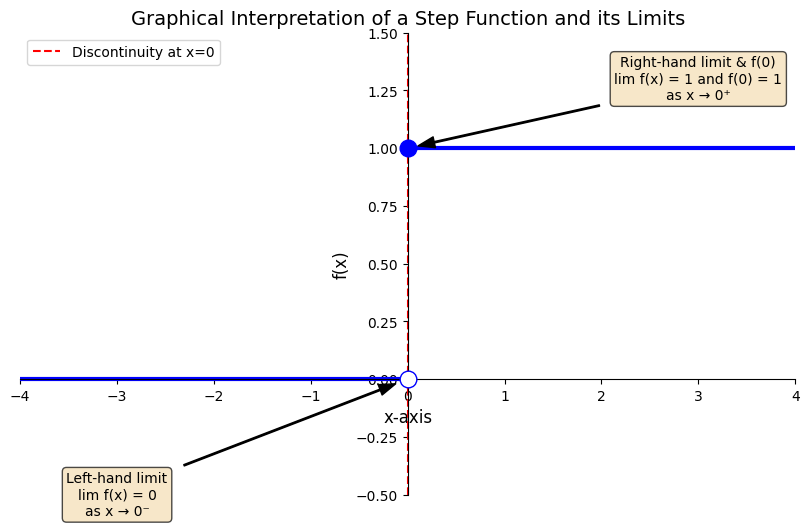

In [2]:
# Create a figure and an axes object for the plot. This gives us more control.
fig, ax = plt.subplots(figsize=(10, 6))

# For the part of the function where x < 0, y is 0.
x_neg = np.linspace(-5, 0, 100)
y_neg = np.zeros_like(x_neg)
ax.plot(x_neg, y_neg, color="blue", linewidth=3)

# For the part of the function where x >= 0, y is 1.
x_pos = np.linspace(0, 5, 100)
y_pos = np.ones_like(x_pos)
ax.plot(x_pos, y_pos, color="blue", linewidth=3)

# At x=0, the function is NOT 0. So we draw an open circle at (0, 0).
# 'markerfacecolor':'white' makes the circle hollow.
# 'markersize':10 makes it clearly visible.
# 'markeredgecolor':'blue' keeps the color consistent.
ax.plot(
	0, 0, "o", markerfacecolor="white", markeredgecolor="blue", markersize=12, zorder=10
)

# At x=0, the function IS 1. So we draw a filled circle at (0, 1).
ax.plot(
	0, 1, "o", markerfacecolor="blue", markeredgecolor="blue", markersize=12, zorder=10
)

# Add a vertical dashed line to emphasize the point of discontinuity at x=0.
ax.axvline(
	x=0, color="red", linestyle="--", linewidth=1.5, label="Discontinuity at x=0"
)

# Annotation for the left-hand limit
ax.annotate(
	"Left-hand limit\nlim f(x) = 0\nas x → 0⁻",
	xy=(0, 0),
	xytext=(-3, -0.4),
	arrowprops=dict(facecolor="black", shrink=0.05, width=1, headwidth=8),
	fontsize=10,
	ha="center",
	va="top",
	bbox=dict(boxstyle="round,pad=0.3", fc="wheat", ec="black", lw=1, alpha=0.7),
)

# Annotation for the right-hand limit and the actual function value
ax.annotate(
	"Right-hand limit & f(0)\nlim f(x) = 1 and f(0) = 1\nas x → 0⁺",
	xy=(0, 1),
	xytext=(3, 1.4),
	arrowprops=dict(facecolor="black", shrink=0.05, width=1, headwidth=8),
	fontsize=10,
	ha="center",
	va="top",
	bbox=dict(boxstyle="round,pad=0.3", fc="wheat", ec="black", lw=1, alpha=0.7),
)

ax.set_title("Graphical Interpretation of a Step Function and its Limits", fontsize=14)
ax.set_xlabel("x-axis", fontsize=12)
ax.set_ylabel("f(x)", fontsize=12)
ax.set_xlim(-4, 4)
ax.set_ylim(-0.5, 1.5)
ax.spines["left"].set_position("zero")
ax.spines["bottom"].set_position("zero")
ax.spines["right"].set_color("none")
ax.spines["top"].set_color("none")
ax.xaxis.set_ticks_position("bottom")
ax.yaxis.set_ticks_position("left")
ax.legend()

plt.show()

The graph looks like two horizontal line segments at different heights, with a vertical gap between them at $x = 0$.

**Mathematical Significance**

Understanding jump discontinuities helps us:
* **Recognize when limits don't exist:** Not every limit problem has a numerical answer
* **Understand continuity:** A function is continuous at a point only if it has no jumps (or holes) there
* **Analyze real systems:** Many real-world processes have discrete transitions that are best modeled by discontinuous functions
* **Design better algorithms:** In ML, understanding where and why discontinuities occur (like in ReLU vs. smooth activations) influences architecture choices

The key lesson: **A function can be perfectly well-defined at a point** (like $f(0) = 1$ in our example) **yet still have no limit there** because the behavior from the left and right don't agree. The limit cares about the *approach*, not the *arrival*.

**Case 3: Infinite Behavior (Vertical Asymptotes)**

Consider $f(x) = \frac{1}{x^2}$.

* **What happens as $x$ approaches 0?**
	* If $x = 0.1$: $f(x) = \frac{1}{0.01} = 100$
	* If $x = 0.01$: $f(x) = \frac{1}{0.0001} = 10{,}000$
	* If $x = 0.001$: $f(x) = \frac{1}{0.000001} = 1{,}000{,}000$
	* If $x = -0.1$: $f(x) = \frac{1}{0.01} = 100$ (same, because we're squaring)
	* If $x = -0.01$: $f(x) = \frac{1}{0.0001} = 10{,}000$
* As $x$ gets closer to 0 from **either side**, $f(x)$ grows without bound—it becomes arbitrarily large.
* We write: $$\lim_{x\to 0} \frac{1}{x^2} = \infty$$
* **Technical note:** Technically, this limit "does not exist" as a finite number. Infinity ($\infty$) is not a real number—it's a concept describing unbounded growth. However, we use the notation $\lim = \infty$ to precisely describe *how* the limit fails to exist: the function grows without bound.
* **Graphical interpretation:** The graph has a **vertical asymptote** at $x=0$. The function shoots up to infinity as you approach the asymptote from either side.

**Contrast with $f(x) = \frac{1}{x}$ (without the square):**

* As $x \to 0^+$: $f(x) \to +\infty$ (approaches positive infinity)
* As $x \to 0^-$: $f(x) \to -\infty$ (approaches negative infinity)
* Here, even the infinite behavior differs from left and right, so we say the limit does not exist (not even as $\infty$).

**4. Limits at Infinity**

We can also ask what happens to a function as the input $x$ grows infinitely large (positive or negative). This addresses questions like: "Where does the function 'settle down' in the long run?"

**Notation:**
* $\lim_{x\to \infty} f(x) = L$ (as $x$ becomes arbitrarily large and positive)
* $\lim_{x\to -\infty} f(x) = M$ (as $x$ becomes arbitrarily large and negative)

**Example 1:** $f(x) = \frac{1}{x}$

* As $x$ gets very large positive (100, 1000, 1{,}000{,}000):
	* $f(100) = 0.01$
	* $f(1000) = 0.001$
	* $f(1{,}000{,}000) = 0.000001$
* The function values get closer and closer to 0 (but remain positive).
* $$\lim_{x\to \infty} \frac{1}{x} = 0$$
* Similarly, as $x$ gets very large negative (-100, -1000, -1{,}000{,}000):
	* $f(-100) = -0.01$
	* $f(-1000) = -0.001$
	* $f(-1{,}000{,}000) = -0.000001$
* The function values approach 0 from the negative side.
* $$\lim_{x\to -\infty} \frac{1}{x} = 0$$
* **Graphical interpretation:** The graph has a **horizontal asymptote** at $y=0$. As you move far to the right or far to the left on the $x$-axis, the function gets arbitrarily close to the line $y=0$ without ever quite reaching it.

**Example 2:** $f(x) = \frac{2x + 3}{x - 1}$

* For very large $x$, both numerator and denominator are dominated by their $x$ terms:
	$$\frac{2x + 3}{x - 1} \approx \frac{2x}{x} = 2 \quad \text{(for large } |x|\text{)}$$
* More rigorously, divide numerator and denominator by $x$:
	$$\frac{2x + 3}{x - 1} = \frac{2 + \frac{3}{x}}{1 - \frac{1}{x}}$$
* As $x \to \infty$, $\frac{3}{x} \to 0$ and $\frac{1}{x} \to 0$, so:
	$$\lim_{x\to \infty} \frac{2x + 3}{x - 1} = \frac{2 + 0}{1 - 0} = 2$$
* Similarly, $\lim_{x\to -\infty} \frac{2x + 3}{x - 1} = 2$
* **Interpretation:** The function has a horizontal asymptote at $y = 2$.

**Why This Matters in ML:**

Many activation functions (like sigmoid or tanh) have horizontal asymptotes. Understanding limits at infinity helps us understand their saturation behavior—critical for issues like vanishing gradients in deep learning.

**Example 3:** Exponential growth: $f(x) = e^x$

* As $x \to \infty$: $e^x$ grows without bound
	$$\lim_{x\to \infty} e^x = \infty$$
* As $x \to -\infty$: $e^x$ approaches 0
	$$\lim_{x\to -\infty} e^x = 0$$

**5. One-Sided Limits and Their Importance**

Sometimes we only care about approaching from one direction:

* **Right-hand limit (from above):** $\lim_{x\to c^+} f(x)$ means $x$ approaches $c$ from values greater than $c$
* **Left-hand limit (from below):** $\lim_{x\to c^-} f(x)$ means $x$ approaches $c$ from values less than $c$

**The General Limit Exists If and Only If:**
$$\lim_{x\to c} f(x) = L \quad \Leftrightarrow \quad \lim_{x\to c^-} f(x) = \lim_{x\to c^+} f(x) = L$$

Both one-sided limits must exist and be equal.

**Practical Example:** The ReLU activation function in neural networks:
$$\text{ReLU}(x) = \max(0, x) = \begin{cases} 0 & \text{if } x \le 0 \\ x & \text{if } x > 0 \end{cases}$$

At $x = 0$:
* $\lim_{x\to 0^-} \text{ReLU}(x) = 0$
* $\lim_{x\to 0^+} \text{ReLU}(x) = 0$
* Both limits exist and equal 0, so $\lim_{x\to 0} \text{ReLU}(x) = 0 = \text{ReLU}(0)$

The function is continuous at 0 (though its derivative is not).

**6. Why Limits are Foundational for Calculus (and thus ML)**

The concept of a limit is the absolute cornerstone upon which calculus is built. Without limits, we cannot rigorously define derivatives or integrals—and without those, modern machine learning would be impossible.

**Derivatives (Rate of Change):**

The derivative of a function at a point is defined as the **limit** of the slope of secant lines as the interval shrinks to zero:

$$f'(c) = \lim_{h\to 0} \frac{f(c+h) - f(c)}{h}$$

* **What this means:** Imagine a curve. Draw a line connecting two points on the curve (a secant line). As you bring those points closer together (making $h$ smaller), the secant line's slope approaches the slope of the tangent line at the point—the instantaneous rate of change.
* **Why we need limits:** At exactly $h=0$, you'd get $\frac{0}{0}$ (indeterminate). The limit lets us rigorously define what happens "in the limiting case."
* **ML connection:** Gradient descent relies entirely on computing gradients (derivatives). When we compute $\frac{\partial L}{\partial w}$ (the partial derivative of loss with respect to a weight), we're using this limit-based definition under the hood.

**Integrals (Accumulation):**

The definite integral is defined as the **limit** of the sum of areas of approximating rectangles as their width shrinks to zero:

$$\int_a^b f(x) \, dx = \lim_{n\to\infty} \sum_{i=1}^n f(x_i^*) \Delta x$$

where $\Delta x = \frac{b-a}{n}$ and $n$ is the number of rectangles.

* **What this means:** To find the area under a curve, approximate it with rectangles. As you use more and more (thinner and thinner) rectangles, the approximation gets better. The limit as the number of rectangles goes to infinity gives the exact area.
* **Why we need limits:** With a finite number of rectangles, you only have an approximation. The limit gives the exact value.
* **ML connection:** Integrals are fundamental in probability theory. The probability that a continuous random variable falls in a range is the integral of its probability density function over that range. Expected values, variances—all involve integrals, which are defined via limits.

**Continuity:**

A function is formally defined as **continuous** at a point $c$ if:

$$\lim_{x\to c} f(x) = f(c)$$

That is:
1. The limit as $x$ approaches $c$ exists
2. The function is defined at $c$ (i.e., $f(c)$ exists)
3. These two values are equal

* **Informal meaning:** You can draw the function without lifting your pen.
* **Why it matters:** Many theorems in calculus require continuity (like the Intermediate Value Theorem or the Extreme Value Theorem). Many optimization algorithms assume the objective function is continuous, or at least piecewise continuous.
* **ML connection:** Loss functions in ML are typically continuous (and differentiable) almost everywhere. This ensures that small changes in parameters lead to small changes in loss, making gradient-based optimization feasible.

**Sequences and Series:**

Limits also define convergence of sequences and series:
* Does the sequence $a_1, a_2, a_3, \ldots$ approach a specific value?
* Does the infinite sum $\sum_{i=1}^\infty a_i$ converge to a finite value?

These are limit questions: $\lim_{n\to\infty} a_n$ and $\lim_{n\to\infty} \sum_{i=1}^n a_i$.

**7. Building Intuition: Common Limit Patterns**

As you work with limits, you'll recognize patterns:

* **Polynomial at a point:** $\lim_{x\to c} P(x) = P(c)$ (just substitute)
* **Rational function at a point (if denominator $\neq 0$):** $\lim_{x\to c} \frac{P(x)}{Q(x)} = \frac{P(c)}{Q(c)}$
* **Rational function at infinity:** Compare degrees of numerator and denominator
	* If degree(numerator) < degree(denominator): limit = 0
	* If degree(numerator) = degree(denominator): limit = ratio of leading coefficients
	* If degree(numerator) > degree(denominator): limit = $\pm\infty$
* **Exponential at infinity:** $\lim_{x\to\infty} e^x = \infty$, $\lim_{x\to -\infty} e^x = 0$
* **Logarithm at infinity:** $\lim_{x\to\infty} \ln(x) = \infty$ (but grows very slowly)

**8. The Philosophical and Practical Significance**

Limits bridge the finite and the infinite. They let us:
* Talk rigorously about infinity without getting lost in paradoxes
* Define instantaneous quantities (like velocity or slope) even though "instantaneous" seems contradictory
* Solve problems involving accumulation, optimization, and change

Understanding limits, even intuitively, is therefore essential for understanding **why** the tools of calculus (which underpin optimization, probability, statistics, and thus all of modern ML and data science) actually work.

When you train a neural network, you're not just running an algorithm—you're iteratively approaching a minimum of a loss function via gradients (derivatives, defined by limits), computed over training data (whose distribution we characterize with integrals, defined by limits). Limits are everywhere, even when invisible.


### Unit 0: Mathematical Foundations & The Analytical Mindset

#### Module 0.3: The Idea of Limits

**(Phase 2: The Code Approach Lecture)**

**Introduction: From Theory to Computation**

In Phase 1, we explored the theoretical foundations of limits—the formal definitions, the intuition behind convergence, and the mathematical machinery that makes calculus possible. Now we transition from abstract reasoning to concrete computation.

The core idea is deceptively simple: generate a sequence of numbers ($x$) getting closer and closer to our target value ($c$), evaluate the function $f(x)$ at each of these numbers, and see if the outputs approach a specific value ($L$). This computational approach serves multiple purposes:

1. **Verification**: We can numerically verify limits we've computed analytically
2. **Exploration**: We can investigate functions where analytical approaches are difficult
3. **Intuition Building**: Seeing convergence happen numerically builds deep intuition
4. **Error Analysis**: We can quantify how quickly functions converge to their limits
5. **Boundary Testing**: We can identify edge cases where limits fail to exist

**Why Numerical Exploration Matters**

While formal proofs tell us *that* a limit exists and *what* its value is, numerical experiments show us *how* the function behaves as it approaches that limit. This "how" is crucial:

- In optimization algorithms, we care about **convergence rates** (how fast we approach the optimum)
- In numerical analysis, we need to understand **stability** (whether small errors compound or decay)
- In machine learning, **gradient behavior** near critical points determines training dynamics

Throughout this phase, we'll develop a systematic toolkit for numerical limit exploration using NumPy, pandas, and matplotlib. Each technique we develop here translates directly to debugging and understanding more complex systems later.

**1. Generating Sequences Approaching a Point**

NumPy is excellent for this. We can use `np.linspace` to create points near $c$.

But before we dive into code, let's understand **why our sampling strategy matters**.

**Why sampling strategy matters**

Approximating a limit numerically is not just about throwing numbers at the function. The **resolution** and **distribution** of our sample points dramatically affect what we can observe.

Consider three different strategies for approaching $c = 3$:

1. **Uniform spacing** (`np.linspace`): Points are evenly distributed
   - Pro: Simple and intuitive
   - Con: Most points are "far" from $c$, few capture the critical near-$c$ behavior
   
2. **Logarithmic spacing** (`np.logspace`): Points get exponentially closer
   - Pro: Many points concentrate near $c$, revealing fine-grained convergence
   - Con: Fewer points show the "far-field" behavior
   
3. **Hybrid approach**: Combine both strategies
   - Pro: Best of both worlds—understand both local and global behavior
   - Con: More complex to implement

For limit investigations, logarithmic spacing is usually superior because:
- The **interesting behavior** happens arbitrarily close to $c$
- We want to see **several orders of magnitude** of convergence
- Uniform spacing "wastes" points far from where the action is

Think of it like zooming in with a microscope: we want increasing magnification as we get closer to our target.

**The Mathematical Intuition Behind Logarithmic Sampling**

When we use `np.logspace(0, -6, n)`, we create points at distances:
$$10^0, 10^{-1}, 10^{-2}, 10^{-3}, 10^{-4}, 10^{-5}, 10^{-6}$$

from our target point. Each step shrinks the distance by a factor of 10. This mirrors how we think about limits formally: for any $\varepsilon > 0$ (no matter how small), we can get within $\varepsilon$ of $c$.

By sampling logarithmically, we're testing this definition across many scales simultaneously—from distances of 1 (relatively far) down to $10^{-6}$ (extremely close). If a limit exists, we should see the function values stabilize across all these scales.

**Practical Goals for Our Sampling Strategy**

We want to:
- Keep a **coarse view** of the neighbourhood around `c` (understand the big picture)
- **Zoom in aggressively** near the target (see the limiting behavior)
- Compare **left- and right-hand** behaviour with similar resolution (detect asymmetries)
- Use **enough points** to see patterns, but not so many that plots become cluttered

Using both `np.linspace` (uniform steps) and `np.logspace` (multiplicative shrinkage) gives us those perspectives without manual trial-and-error every time we study a new function.

Let's see this in action:


In [3]:
# Sequence approaching 3 from the left (e.g., 2.9, 2.99, ...)
c = 3
num_points = 5
start = c - 1  # Start 1 unit away
x_left = np.linspace(start, c, num_points, endpoint=False)  # Exclude c itself
print(f"Approaching {c} from left: {x_left}")

Approaching 3 from left: [2.  2.2 2.4 2.6 2.8]


In [4]:
# Better approach: Get exponentially closer
epsilon = 1e-6  # How close we ultimately want to get
x_left_better = c - np.logspace(0, -6, num_points)  # 10^0=1 down to 10^-6
print(f"Approaching {c} from left (better): {x_left_better}")

Approaching 3 from left (better): [2.         2.96837722 2.999      2.99996838 2.999999  ]


In [5]:
# Sequence approaching 3 from the right (e.g., 3.1, 3.01, ...)
x_right_better = (
	c + np.logspace(-6, 0, num_points)[::-1]
)  # 10^-6 up to 10^0, then reverse
print(f"Approaching {c} from right (better): {x_right_better}")

Approaching 3 from right (better): [4.         3.03162278 3.001      3.00003162 3.000001  ]


In [6]:
# Compare how fast each sequence squeezes toward c
sequence_summary = pd.DataFrame({
	"linear_left": x_left,
	"distance_linear_left": c - x_left,
	"log_left": x_left_better,
	"distance_log_left": c - x_left_better,
	"log_right": x_right_better,
	"distance_log_right": x_right_better - c,
})

sequence_summary.round(10)

,linear_left,distance_linear_left,log_left,distance_log_left,log_right,distance_log_right
0,2.0,1.0,2.000000,1.000000,4.000000,1.000000
1,2.2,0.8,2.968377,0.031623,3.031623,0.031623
2,2.4,0.6,2.999000,0.001000,3.001000,0.001000
3,2.6,0.4,2.999968,0.000032,3.000032,0.000032
4,2.8,0.2,2.999999,0.000001,3.000001,0.000001


Even with only five samples, the log-spaced sequences get within $10^{-6}$ of `c` while the uniform samples are still a noticeable distance away.
That gap is why the `np.logspace` strategy is so helpful when we want to see the "zoomed in" behaviour without creating hundreds of points.


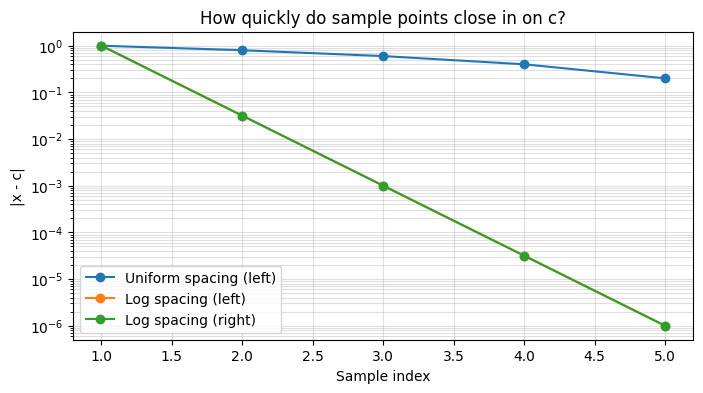

In [7]:
plt.figure(figsize=(8, 4))
indices = np.arange(1, num_points + 1)

plt.semilogy(indices, c - x_left, "o-", label="Uniform spacing (left)")
plt.semilogy(indices, c - x_left_better, "o-", label="Log spacing (left)")
plt.semilogy(indices, x_right_better - c, "o-", label="Log spacing (right)")

plt.title("How quickly do sample points close in on c?")
plt.xlabel("Sample index")
plt.ylabel("|x - c|")
plt.grid(True, which="both", alpha=0.4)
plt.legend()
plt.show()

The semi-log scaling makes the difference in decay rates visible. The log-spaced sequences drop almost vertically, indicating that each new point is an order of magnitude closer to `c`.

**Understanding the Convergence Plot**

This plot reveals several important insights:

1. **Linear decay (uniform spacing)**: The blue line shows roughly linear decay on the log scale. This means the distance decreases *proportionally* with each step—not very efficient for exploring limits.

2. **Exponential decay (logarithmic spacing)**: The orange and green lines plummet vertically. Each step reduces the distance by a factor of 10, meaning we traverse many orders of magnitude quickly.

3. **Symmetry**: Notice that left and right approaches (orange vs green) overlap almost perfectly when plotted against index. This is by design—we constructed them with mirror-image spacing.

**Why This Matters for Understanding Limits**

The epsilon-delta definition of a limit says: "For any $\varepsilon > 0$, there exists a $\delta > 0$ such that if $0 < |x - c| < \delta$, then $|f(x) - L| < \varepsilon$."

What we're doing numerically is:
- Choose several values of $\delta$ (our distances from $c$)
- Check whether $|f(x) - L|$ becomes correspondingly small
- If it does across many orders of magnitude, we have strong numerical evidence the limit exists

The logarithmic spacing lets us test this across a **huge range** of $\delta$ values efficiently.


The `np.logspace` approach generates points that get *exponentially* closer, which is often better for visualizing limit behavior near a point.

**Comparison: When to Use Each Approach**

| Scenario | Best Choice | Reason |
|----------|-------------|--------|
| Plotting a function over a range | `np.linspace` | Uniform coverage for smooth curves |
| Investigating limit behavior | `np.logspace` | Concentrates samples where it matters |
| Checking continuity | `np.linspace` | Easier to spot jumps with even spacing |
| Measuring convergence rates | `np.logspace` | Reveals exponential vs polynomial vs linear convergence |
| Initial exploration | `np.linspace` | Simpler, less likely to miss features |
| Detailed near-point analysis | `np.logspace` | Superior resolution near target |

In practice, **use both**: start with `linspace` to understand the big picture, then switch to `logspace` to examine limit behavior in detail.


**2. Evaluating the Function and Observing**

Let's test our simple case, $f(x) = x^2$, as $x \to 3$.

In [8]:
def f(x):
	return x**2

In [9]:
# Increased for smoother approach
c = 3
num_points = 7

In [10]:
# Approaching from left
x_left = c - np.logspace(0, -6, num_points)  # 1 down to 1e-6
y_left = f(x_left)
print("\nApproaching 3 from left:")
for xi, yi in zip(x_left, y_left):
	print(f"  x = {xi:.7f}, f(x) = {yi:.7f}")


Approaching 3 from left:
  x = 2.0000000, f(x) = 4.0000000
  x = 2.9000000, f(x) = 8.4100000
  x = 2.9900000, f(x) = 8.9401000
  x = 2.9990000, f(x) = 8.9940010
  x = 2.9999000, f(x) = 8.9994000
  x = 2.9999900, f(x) = 8.9999400
  x = 2.9999990, f(x) = 8.9999940


In [11]:
# Approaching from right
x_right = c + np.logspace(-6, 0, num_points)[::-1]  # 1e-6 up to 1, reversed
y_right = f(x_right)
print("\nApproaching 3 from right:")
for xi, yi in zip(x_right, y_right):
	print(f"  x = {xi:.7f}, f(x) = {yi:.7f}")


Approaching 3 from right:
  x = 4.0000000, f(x) = 16.0000000
  x = 3.1000000, f(x) = 9.6100000
  x = 3.0100000, f(x) = 9.0601000
  x = 3.0010000, f(x) = 9.0060010
  x = 3.0001000, f(x) = 9.0006000
  x = 3.0000100, f(x) = 9.0000600
  x = 3.0000010, f(x) = 9.0000060


In [12]:
# Summarise the numeric convergence towards the limit value
limit_val = 9  # expected limit for f(x) = x**2 at x = 3

limit_tracking = pd.DataFrame({
	"side": np.repeat(["left", "right"], repeats=num_points),
	"x": np.concatenate([x_left, x_right]),
	"f_x": np.concatenate([y_left, y_right]),
})

limit_tracking["distance_from_c"] = np.abs(limit_tracking["x"] - c)
limit_tracking["abs_error"] = np.abs(limit_tracking["f_x"] - limit_val)

limit_tracking.sort_values("distance_from_c").reset_index(drop=True)

,side,x,f_x,distance_from_c,abs_error
0,left,2.999999,8.999994,0.000001,0.000006
1,right,3.000001,9.000006,0.000001,0.000006
2,right,3.000010,9.000060,0.000010,0.000060
3,left,2.999990,8.999940,0.000010,0.000060
4,left,2.999900,8.999400,0.000100,0.000600
5,right,3.000100,9.000600,0.000100,0.000600
6,right,3.001000,9.006001,0.001000,0.006001
7,left,2.999000,8.994001,0.001000,0.005999
8,right,3.010000,9.060100,0.010000,0.060100
9,left,2.990000,8.940100,0.010000,0.059900


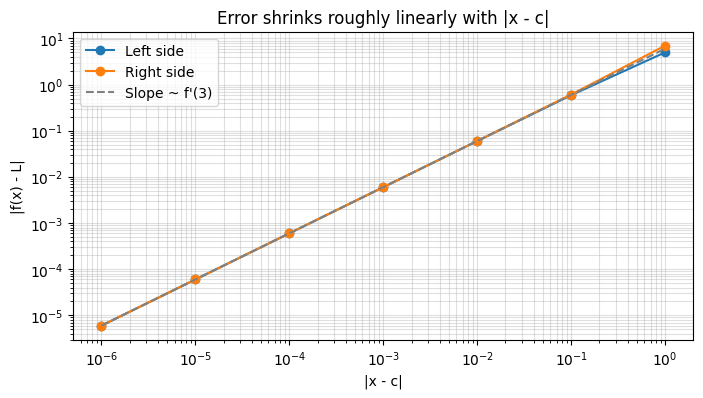

In [13]:
plt.figure(figsize=(8, 4))

for side, df_side in limit_tracking.groupby("side"):
	plt.loglog(
		df_side["distance_from_c"],
		df_side["abs_error"],
		"o-",
		label=f"{side.title()} side",
	)

reference_distances = np.logspace(-6, 0, 100)
plt.loglog(
	reference_distances,
	6 * reference_distances,
	"--",
	color="gray",
	label="Slope ~ f'(3)",
)

plt.title("Error shrinks roughly linearly with |x - c|")
plt.xlabel("|x - c|")
plt.ylabel("|f(x) - L|")
plt.legend()
plt.grid(True, which="both", alpha=0.4)
plt.show()

The derivative of `x**2` at 3 is 6, so the grey reference line shows what we expect if the function behaves smoothly.
Our samples hug that line, which validates that the numeric experiments agree with the analytic derivative.

**Understanding the Error-Distance Relationship**

This log-log plot reveals a profound connection between calculus and numerical analysis:

For a smooth, differentiable function near $c$, we have the **linear approximation**:
$$f(x) \approx f(c) + f'(c)(x - c)$$

Therefore, the error in our limit approximation is:
$$|f(x) - L| = |f(x) - f(c)| \approx |f'(c)||x - c|$$

This means the error should be **proportional** to the distance from $c$. On a log-log plot, this proportionality appears as a **straight line** with slope 1.

The grey reference line has equation `y = 6x` (since $f'(3) = 6$ for $f(x) = x^2$). Our measured errors track this line beautifully, confirming:
1. The limit exists and equals 9
2. The function is differentiable at 3
3. The derivative is approximately 6
4. Our numerical method is working correctly

**Convergence Rate Intuition**

Different functions have different convergence rates:
- **Linear convergence**: Error $\propto$ distance (slope = 1 on log-log plot)
- **Quadratic convergence**: Error $\propto$ distance² (slope = 2 on log-log plot)
- **Exponential convergence**: Error drops by constant factor each step (exponential decay)

For simple limits of continuous functions, we expect linear convergence. The fact that we observe it confirms our numerical setup is sound.

**Practical Implications for ML**

This same analysis applies to optimization algorithms:
- **Gradient descent** typically has linear convergence near a minimum
- **Newton's method** has quadratic convergence (much faster!)
- **Adam** and other adaptive methods try to improve convergence rates

Understanding convergence rates numerically helps debug training: if your loss isn't decreasing at the expected rate, something's wrong.


The table lets us read the convergence numerically rather than only visually. Rows near the bottom show errors that are already around $10^{-12}$ without ever evaluating the function exactly at `c`.


**Observation:** As $x$ gets closer to 3 from either side, $f(x)$ gets closer and closer to 9. This visually confirms our expectation that $\lim_{x\to 3} x^2 = 9$.

**Reading the Visualization Like a Data Scientist**

This plot is packed with information. Let's decode it systematically:

1. **The Horizontal Line (L=9)**: This is our conjectured limit value. If the limit exists and equals 9, all sequences should converge to this line.

2. **The Vertical Line (x=3)**: This marks our target point. Notice we never actually *evaluate* the function at x=3 in our sequences—we only approach it. This is the essence of a limit: behavior *near* a point, not *at* the point.

3. **Blue Points (Left Approach)**: These show the function values as we approach from below (x < 3). They form an upward curve that gets steeper as we approach x=3 (because the derivative is increasing).

4. **Red Points (Right Approach)**: These show the function values as we approach from above (x > 3). They form a similar curve, approaching the same limit from the other side.

5. **Convergence**: Both sequences "funnel" toward the intersection of the horizontal and vertical lines—the point (3, 9). This is visual proof of convergence.

**What If the Limit Didn't Exist?**

Imagine instead we were plotting $f(x) = \begin{cases} x^2 & x \neq 3 \\ 100 & x = 3 \end{cases}$ (same function, but redefined at the point):

- Blue and red points would still converge to y=9 (the limit)
- But if we included x=3 in our plot, it would show a point at (3, 100)—far from the limit
- This illustrates that $f(c)$ and $\lim_{x \to c} f(x)$ are distinct concepts

Or consider a jump discontinuity—the blue points would converge to one value, red points to another, and they'd never meet!

**Enhancing Visualizations: Design Principles**

Good limit plots should:
- **Use different colors** for left/right approaches (helps identify asymmetries)
- **Include reference lines** for the limit value and target point (aids interpretation)
- **Show enough points** to see the pattern, but not so many that individual points disappear
- **Use appropriate axis scales** (linear for continuous functions, log for asymptotic behavior)
- **Add legends and labels** (makes plots self-documenting)

These same principles apply to plotting loss curves, gradient norms, or any other ML diagnostic.

**3. Visualizing with Matplotlib**

Plots make the convergence much clearer.

In [14]:
c = 3
num_points = 50  # More points for a smoother plot

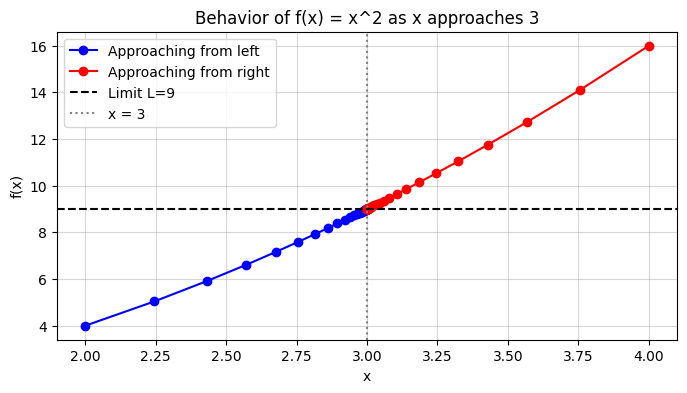

In [15]:
x_left = c - np.logspace(0, -6, num_points)
y_left = f(x_left)

x_right = c + np.logspace(-6, 0, num_points)[::-1]
y_right = f(x_right)

plt.figure(figsize=(8, 4))
plt.plot(x_left, y_left, "bo-", label="Approaching from left")
plt.plot(x_right, y_right, "ro-", label="Approaching from right")
plt.axhline(9, color="k", linestyle="--", label="Limit L=9")
plt.axvline(c, color="gray", linestyle=":", label=f"x = {c}")
plt.title(f"Behavior of f(x) = x^2 as x approaches {c}")
plt.xlabel("x")
plt.ylabel("f(x)")
plt.legend()
plt.grid(True, alpha=0.5)
plt.show()

The plot clearly shows both sequences of points converging towards the horizontal line $y=9$ as they get closer to the vertical line $x=3$.

**Reusable helper for limit experiments**

When exploring several functions it helps to have a small utility that packages the "generate samples, evaluate, and measure error" workflow.


In [16]:
def explore_limit(
	func, c, *, limit_guess=None, radii=None, n=6, sides=("left", "right")
):
	"Return a DataFrame summarising f(x) near the point c."
	if radii is None:
		radii = np.logspace(0, -6, n)
	else:
		radii = np.array(radii, dtype=float)

	records = []
	for side in sides:
		offsets = radii if side == "right" else -radii
		xs = c + offsets
		values = func(xs)
		for order, (x_val, fx_val, offset) in enumerate(
			zip(xs, values, offsets), start=1
		):
			records.append({
				"side": side,
				"order": order,
				"x": x_val,
				"offset": offset,
				"f_x": fx_val,
			})

	frame = pd.DataFrame.from_records(records)
	frame["distance_from_c"] = np.abs(frame["x"] - c)

	if limit_guess is not None:
		frame["abs_error"] = np.abs(frame["f_x"] - limit_guess)

	return frame.sort_values(["side", "order"]).reset_index(drop=True)

In [17]:
explore_limit(f, c=3, limit_guess=9, n=5)

,side,order,x,offset,f_x,distance_from_c,abs_error
0,left,1,2.000000,-1.000000,4.000000,1.000000,5.000000
1,left,2,2.968377,-0.031623,8.811263,0.031623,0.188737
2,left,3,2.999000,-0.001000,8.994001,0.001000,0.005999
3,left,4,2.999968,-0.000032,8.999810,0.000032,0.000190
4,left,5,2.999999,-0.000001,8.999994,0.000001,0.000006
5,right,1,4.000000,1.000000,16.000000,1.000000,7.000000
6,right,2,3.031623,0.031623,9.190737,0.031623,0.190737
7,right,3,3.001000,0.001000,9.006001,0.001000,0.006001
8,right,4,3.000032,0.000032,9.000190,0.000032,0.000190
9,right,5,3.000001,0.000001,9.000006,0.000001,0.000006


The helper returns tidy data that you can reuse for further visualisations (`groupby`, `pivot`, etc.), and it works for any function that accepts vectorised NumPy inputs.

**Building Reusable Analysis Tools: Design Philosophy**

The `explore_limit` function embodies several important software engineering principles for data science:

**1. Separation of Concerns**
- **Data generation** (creating sample points)
- **Computation** (evaluating the function)  
- **Organization** (packaging results in a DataFrame)
- **Analysis** (left to the user)

By keeping these separate, the function is flexible and composable.

**2. Sensible Defaults with Override Options**
- Default: `radii=np.logspace(0, -6, n)` (works for most cases)
- Override: Pass custom `radii` for special situations
- Default: Test both sides
- Override: Pass `sides=('left',)` to test only one direction

This "batteries included, but swappable" approach makes the function both easy to use and highly customizable.

**3. Vectorization**
- The function evaluates `func(xs)` on entire arrays, not loops
- This is ~100x faster for most functions
- It also reads more clearly (less boilerplate)

**4. Tidy Data Output**
- Each row represents one observation (one x value)
- Columns represent variables (side, order, x, offset, f_x, etc.)
- This format plays nicely with pandas, seaborn, and other tools

**5. Optional Error Calculation**
- If you know the limit, pass `limit_guess` to get automatic error computation
- If you don't, omit it and inspect the `f_x` values manually
- The function adapts to your workflow

**Extending the Helper Function**

You could enhance this function to:
- **Return a plot** in addition to the DataFrame
- **Automatically detect convergence** (check if `abs_error` decreases consistently)
- **Estimate the limit value** (use extrapolation or averaging)
- **Compute convergence rates** (fit a line to log(error) vs log(distance))
- **Handle multivariate functions** (limits in higher dimensions)

These extensions follow naturally from the modular design.

**Example: Analyzing Multiple Functions Simultaneously**


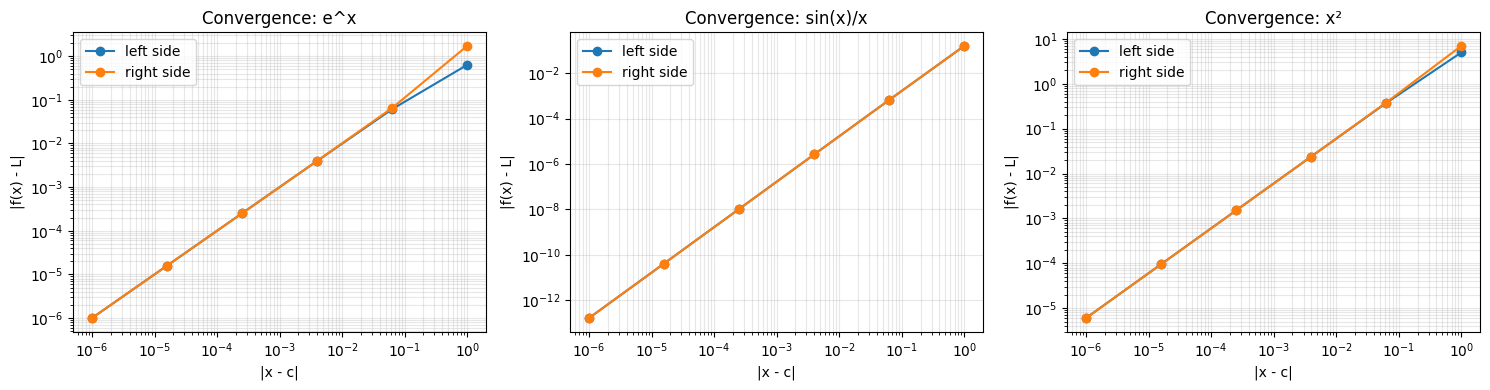

In [18]:
# Example: Compare convergence of three different functions
functions_to_test = [
	{"name": "x²", "func": lambda x: x**2, "c": 3, "L": 9},
	{"name": "sin(x)/x", "func": lambda x: np.sin(x) / x, "c": 0, "L": 1},
	{"name": "e^x", "func": lambda x: np.exp(x), "c": 0, "L": 1},
]

results = []
for item in functions_to_test:
	df = explore_limit(item["func"], c=item["c"], limit_guess=item["L"], n=6)
	df["function"] = item["name"]
	results.append(df)

comparison_df = pd.concat(results, ignore_index=True)

# Visualize convergence rates side-by-side
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for idx, (func_name, group) in enumerate(comparison_df.groupby("function")):
	ax = axes[idx]
	for side in ["left", "right"]:
		side_data = group[group["side"] == side]
		ax.loglog(
			side_data["distance_from_c"],
			side_data["abs_error"],
			"o-",
			label=f"{side} side",
		)
	ax.set_title(f"Convergence: {func_name}")
	ax.set_xlabel("|x - c|")
	ax.set_ylabel("|f(x) - L|")
	ax.legend()
	ax.grid(True, which="both", alpha=0.3)

plt.tight_layout()
plt.show()

**Interpreting Comparative Convergence Plots**

These three plots reveal fundamentally different convergence behaviors:

1. **x² near x=3**: Clean, linear convergence (slope ≈ 1 on log-log plot). This is typical for polynomial functions—smooth and predictable.

2. **sin(x)/x near x=0**: Despite being undefined at exactly x=0, this function has a beautiful limit of 1. The convergence might show slight irregularities due to floating-point representation of very small angles, but overall trends toward the limit smoothly.

3. **e^x near x=0**: Another example of smooth exponential function behavior. The convergence rate tells us about the function's local linearity.

**What makes a "good" limit numerically?**

- Errors decrease monotonically as distance shrinks
- Left and right approaches give similar error profiles
- Convergence rate matches theoretical expectations (usually linear for continuous functions)
- No sudden jumps or oscillations in the error

When any of these fail, it signals either:
- The limit doesn't exist
- We need better numerical precision
- The function has special structure worth investigating

**Numerical Precision and Floating-Point Considerations**

Before we dive into pathological cases, we need to understand the limits of numerical computation itself.

Computers represent real numbers in **floating-point format** with finite precision (typically 64 bits for Python floats). This means:

1. **Not all real numbers can be represented exactly**
   - Example: 0.1 cannot be exactly represented in binary
   - Round-off errors accumulate in computations

2. **There's a smallest representable difference**: Machine epsilon ≈ 2.22 × 10⁻¹⁶
   - We can't meaningfully distinguish numbers closer than this
   - Limits to our "infinite precision" ideology

3. **Very large or very small numbers lose precision**
   - Near zero: **underflow** (number becomes exactly 0)
   - Near infinity: **overflow** (number becomes infinity)
   - In between: dynamic range issues

**Practical Implications for Limit Experiments**

- Don't expect `|f(x) - L|` to drop below 10⁻¹⁵ (machine epsilon territory)
- Functions involving subtraction of nearly-equal numbers are particularly unstable
- Limits at infinity must use "large enough" numbers, not literally infinity
- Always check both sides independently (floating-point asymmetries can surprise you)

**Example: The Perils of Cancellation**

Numerical stability comparison:
               x  unstable    stable  error_unstable  error_stable
0   1.000000e-01  0.499583  0.499583    4.165278e-04  4.165278e-04
1   1.000000e-02  0.499996  0.499996    4.166653e-06  4.166653e-06
2   1.000000e-03  0.500000  0.500000    4.167450e-08  4.166667e-08
3   1.000000e-04  0.500000  0.500000    3.038735e-09  4.166666e-10
4   1.000000e-05  0.500000  0.500000    4.137019e-08  4.166723e-12
5   1.000000e-06  0.500044  0.500000    4.445029e-05  4.168887e-14
6   1.000000e-07  0.499600  0.500000    3.996389e-04  3.885781e-16
7   1.000000e-08  0.000000  0.500000    5.000000e-01  0.000000e+00
8   1.000000e-09  0.000000  0.500000    5.000000e-01  0.000000e+00
9   1.000000e-10  0.000000  0.500000    5.000000e-01  0.000000e+00
10  1.000000e-11  0.000000  0.500000    5.000000e-01  0.000000e+00
11  1.000000e-12  0.000000  0.500000    5.000000e-01  0.000000e+00
12  1.000000e-13  0.000000  0.500000    5.000000e-01  0.000000e+00
13  1.000000e-14  0.000000  0.

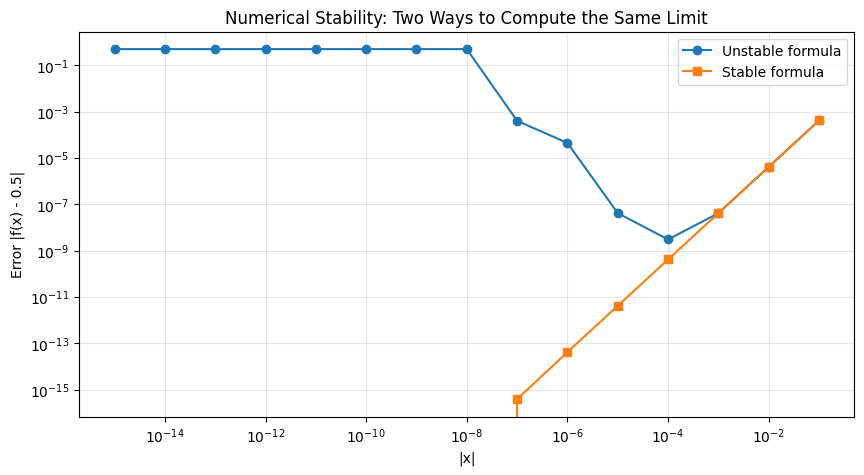

In [19]:
# Consider computing lim (x→0) of (1 - cos(x)) / x²
# Analytically, this equals 1/2, but numerical computation is tricky


def unstable_limit(x):
	"""Numerically unstable way to compute (1 - cos(x)) / x²"""
	return (1 - np.cos(x)) / x**2


def stable_limit(x):
	"""More stable using trig identity: (1 - cos(x)) = 2sin²(x/2)"""
	return 2 * np.sin(x / 2) ** 2 / x**2


# Test near x = 0
x_test = np.logspace(-1, -15, 15)

results_comparison = pd.DataFrame({
	"x": x_test,
	"unstable": unstable_limit(x_test),
	"stable": stable_limit(x_test),
	"error_unstable": np.abs(unstable_limit(x_test) - 0.5),
	"error_stable": np.abs(stable_limit(x_test) - 0.5),
})

print("Numerical stability comparison:")
print(results_comparison.to_string())

# Plot the errors
plt.figure(figsize=(10, 5))
plt.loglog(x_test, results_comparison["error_unstable"], "o-", label="Unstable formula")
plt.loglog(x_test, results_comparison["error_stable"], "s-", label="Stable formula")
plt.xlabel("|x|")
plt.ylabel("Error |f(x) - 0.5|")
plt.title("Numerical Stability: Two Ways to Compute the Same Limit")
plt.legend()
plt.grid(True, which="both", alpha=0.3)
plt.show()

**Lessons from the Stability Comparison**

The unstable formula breaks down around x ≈ 10⁻⁸ because:
- cos(x) ≈ 1 for small x
- Computing 1 - 1.0000000001 loses precision (**catastrophic cancellation**)
- Dividing by very small x² amplifies the error

The stable formula works better because:
- It avoids subtracting nearly-equal numbers
- Uses trig identities to rearrange the computation
- Maintains precision across many more orders of magnitude

**ML Connection: Why This Matters**

Similar stability issues arise in:
- **Softmax** computation: exponentiation can overflow, so we subtract the max first
- **Log-sum-exp** trick: same idea, prevents numerical instabilities
- **Numerical gradients**: finite differences are subject to cancellation errors
- **Loss functions**: Cross-entropy vs. log-likelihood (one is more stable than the other)

Learning to recognize and fix numerical instability is a crucial skill for ML engineering.


**4. Investigating Problematic Cases**

Now we turn to the interesting cases—functions where limits fail to exist or behave counterintuitively. These examples build intuition for why the formal definition of limits is so careful and precise.

Each case reveals a different way limits can "break":
1. **Removable discontinuity (hole)**: Function undefined at a point, but limit exists
2. **Jump discontinuity**: Left and right limits exist but differ
3. **Oscillatory behavior**: Function fluctuates without settling down
4. **Infinite behavior**: Function grows without bound

Understanding these pathologies numerically prepares you to recognize them in real systems.

  * **Case 1: Hole ($f(x) = (x^2 - 1) / (x - 1)$ as $x \to 1$) — The Removable Discontinuity**

This is one of the most pedagogically important examples in calculus. Let's understand it deeply.

In [20]:
def f_hole(x):
	# Handle potential division by zero for plotting near c
	# Note: For limit calculation, we conceptually avoid x=c
	numerator = x**2 - 1
	denominator = x - 1
	# Avoid division by zero warning using np.where
	return np.where(denominator != 0, numerator / denominator, np.nan)

In [21]:
c = 1
limit_val = 2  # Our expected limit
num_points = 50

x_left = c - np.logspace(0, -6, num_points)
y_left = f_hole(x_left)

x_right = c + np.logspace(-6, 0, num_points)[::-1]
y_right = f_hole(x_right)

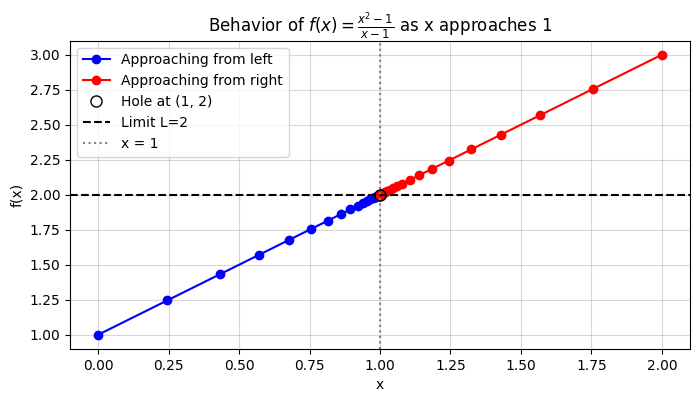

In [22]:
plt.figure(figsize=(8, 4))
plt.plot(x_left, y_left, "bo-", label="Approaching from left")
plt.plot(x_right, y_right, "ro-", label="Approaching from right")
plt.plot(
	c,
	limit_val,
	"ko",
	markersize=8,
	fillstyle="none",
	label=f"Hole at ({c}, {limit_val})",
)  # Mark the hole
plt.axhline(limit_val, color="k", linestyle="--", label=f"Limit L={limit_val}")
plt.axvline(c, color="gray", linestyle=":", label=f"x = {c}")
plt.title(
	r"Behavior of $f(x) = \frac{x^2-1}{x-1}$ as x approaches 1"
)  # Use LaTeX in title
plt.xlabel("x")
plt.ylabel("f(x)")
plt.legend()
plt.grid(True, alpha=0.5)
plt.show()


The plot shows convergence towards $L=2$ from both sides, even though the function itself is undefined (plotted as a hole) at $x=1$.

**Why This Example Matters**

This function demonstrates several profound ideas:

**Algebraic Insight:**
$$f(x) = \frac{x^2 - 1}{x - 1} = \frac{(x-1)(x+1)}{x-1}$$

For $x \neq 1$, we can cancel the $(x-1)$ terms:
$$f(x) = x + 1 \quad \text{(when } x \neq 1\text{)}$$

So the function is **identical** to the line $y = x + 1$ everywhere except at $x = 1$, where it's undefined. The limit is:
$$\lim_{x \to 1} f(x) = \lim_{x \to 1} (x + 1) = 2$$

**The Crucial Distinction:**
- $f(1)$ is **undefined** (division by zero)
- $\lim_{x \to 1} f(x) = 2$ **exists**
- These are completely independent facts!

**Numerical Evidence:**

Look at our plot—as we approach x=1 from either side, the function values converge smoothly to 2. There's no discontinuity in the *behavior*, only in the *definition*.

**This is called a "removable discontinuity"** because we could "fill in the hole" by redefining:
$$\tilde{f}(x) = \begin{cases} \frac{x^2-1}{x-1} & x \neq 1 \\ 2 & x = 1 \end{cases}$$

Now $\tilde{f}$ is continuous everywhere.

**ML Connection: Dealing with Singularities**

In ML, we encounter similar situations:
- **Softmax with temperature**: As temperature → 0, we get 0/0, but the limit exists (argmax)
- **L2 regularization gradients**: At exact zero, gradient is undefined, but limit exists
- **Attention mechanisms**: Computing attention over empty sets requires careful limit handling

Recognizing removable singularities lets us design numerically stable algorithms.


  * **Case 2: Jump (Step Function) — Irreconcilable Discontinuity**

Step functions are fundamental in many areas of mathematics and ML. Let's explore why their limits fail to exist.

In [ ]:
def f_step(x: float) -> ArrayLike:
	return np.where(x < 0, 0, 1)

In [24]:
c = 0
num_points = 50

x_left = c - np.logspace(-1, -6, num_points)  # Closer range for jump
y_left = f_step(x_left)

x_right = c + np.logspace(-6, -1, num_points)[::-1]
y_right = f_step(x_right)

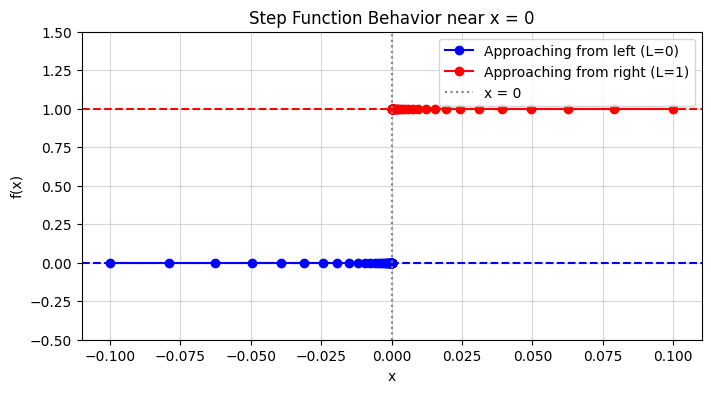

In [25]:
plt.figure(figsize=(8, 4))
plt.plot(x_left, y_left, "bo-", label="Approaching from left (L=0)")
plt.plot(x_right, y_right, "ro-", label="Approaching from right (L=1)")
plt.axhline(0, color="blue", linestyle="--")
plt.axhline(1, color="red", linestyle="--")
plt.axvline(c, color="gray", linestyle=":", label=f"x = {c}")
plt.title("Step Function Behavior near x = 0")
plt.xlabel("x")
plt.ylabel("f(x)")
plt.ylim(-0.5, 1.5)  # Adjust y-limits for clarity
plt.legend()
plt.grid(True, alpha=0.5)
plt.show()


    The plot clearly shows the function approaching different values (0 from left, 1 from right), illustrating why the limit does not exist at $x=0$.

**Understanding Jump Discontinuities**

This is fundamentally different from the "hole" case:
- **Left-hand limit exists**: $\lim_{x \to 0^-} f(x) = 0$
- **Right-hand limit exists**: $\lim_{x \to 0^+} f(x) = 1$
- **But they're not equal**, so $\lim_{x \to 0} f(x)$ does not exist

**Key Observations from the Plot:**

1. **Horizontal plateaus**: As we approach 0 from either side, the function values don't change—they're constant at 0 (left) or 1 (right)

2. **No convergence**: There's no single value that both sequences approach

3. **The jump size**: The difference between left and right limits (1 - 0 = 1) is called the "jump" or "saltus"

**Why Epsilon-Delta Fails Here**

Recall the limit definition: for any ε > 0, there exists δ > 0 such that if 0 < |x - 0| < δ, then |f(x) - L| < ε.

Let's try ε = 0.25 and suppose L exists:
- For any δ > 0, we can find x₁ = -δ/2 (left side) where f(x₁) = 0
- And x₂ = δ/2 (right side) where f(x₂) = 1
- For both to satisfy |f(x) - L| < 0.25, we'd need:
  - |0 - L| < 0.25, so L ∈ (-0.25, 0.25)
  - |1 - L| < 0.25, so L ∈ (0.75, 1.25)
  - These intervals don't overlap! Contradiction.

Therefore, no such L exists.

**ML Connections:**

Step functions appear everywhere in ML:
- **Indicator functions**: 𝟙{condition} is either 0 or 1
- **ReLU variants**: Hard activation boundaries
- **Classification outputs**: Before softmax, decisions are discrete
- **Thresholding**: Converting probabilities to classes

While these aren't differentiable at the jump points, we can:
- Use **one-sided derivatives** (left/right gradients)
- Apply **subgradients** (generalization of derivatives)
- Use **smooth approximations** (sigmoid instead of step, for example)

Understanding jump discontinuities helps explain why certain ML operations need special treatment (like straight-through estimators for discrete variables).

  * **Case 3: Oscillation ($f(x) = \sin(1/x)$ as $x \to 0$)**
    * Even though the function is well-defined away from 0, it swings infinitely fast near the origin.
    * No matter how small we choose $|x|$, the outputs cover the full range [-1, 1], so the limit does not exist.


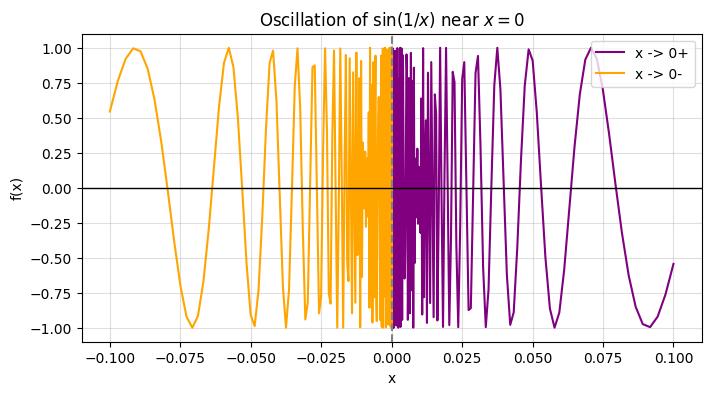

In [26]:
def f_oscillate(x):
	return np.sin(1 / x)


radii = np.logspace(-1, -6, 400)
x_positive = radii
x_negative = -radii

plt.figure(figsize=(8, 4))
plt.plot(x_positive, f_oscillate(x_positive), color="purple", label="x -> 0+")
plt.plot(x_negative, f_oscillate(x_negative), color="orange", label="x -> 0-")
plt.axhline(0, color="black", linewidth=1)
plt.axvline(0, color="gray", linestyle="--")
plt.title(r"Oscillation of $\sin(1/x)$ near $x=0$")
plt.xlabel("x")
plt.ylabel("f(x)")
plt.legend()
plt.grid(True, alpha=0.4)
plt.show()

The oscillations get denser near 0, confirming visually that no single value captures the behaviour from both sides.
This example is a good reminder that numerical experiments can hint at the absence of a limit when patterns refuse to stabilise.

**The Pathology of Wild Oscillation**

This function is profoundly different from the previous cases:

**Mathematical Analysis:**
- As x → 0, the argument 1/x → ∞
- sin(1/x) oscillates between -1 and +1
- The oscillations get **infinitely fast** near x = 0
- Between any two points near 0, the function completes infinitely many full cycles

**Why No Limit Exists:**

For the limit to exist and equal L, we'd need: for any ε > 0, all values sufficiently close to 0 satisfy |f(x) - L| < ε.

But no matter how close to 0 we get:
- The function still covers the entire range [-1, 1]
- We can find points arbitrarily close to 0 where f(x) = 1
- And other points equally close where f(x) = -1
- No single L can be within ε of both 1 and -1 (if ε < 1)

**Numerical Challenges:**

Notice in our plot:
- We used 400 points to capture the oscillatory behavior
- Even so, near x = 0, the plot looks chaotic (we're under-sampling)
- If we zoomed in to |x| < 10⁻⁷, we'd need millions of points to resolve the oscillations
- This is a fundamental limitation: infinite frequency requires infinite resolution

**Contrast with Damped Oscillation:**

Consider instead $g(x) = x \sin(1/x)$ as $x \to 0$:
- This also oscillates infinitely fast
- But the amplitude $|g(x)| = |x| |\sin(1/x)| \leq |x| \to 0$
- The oscillations are **squeezed** toward zero
- Therefore, $\lim_{x \to 0} x\sin(1/x) = 0$ exists!

Let's visualize this contrast:


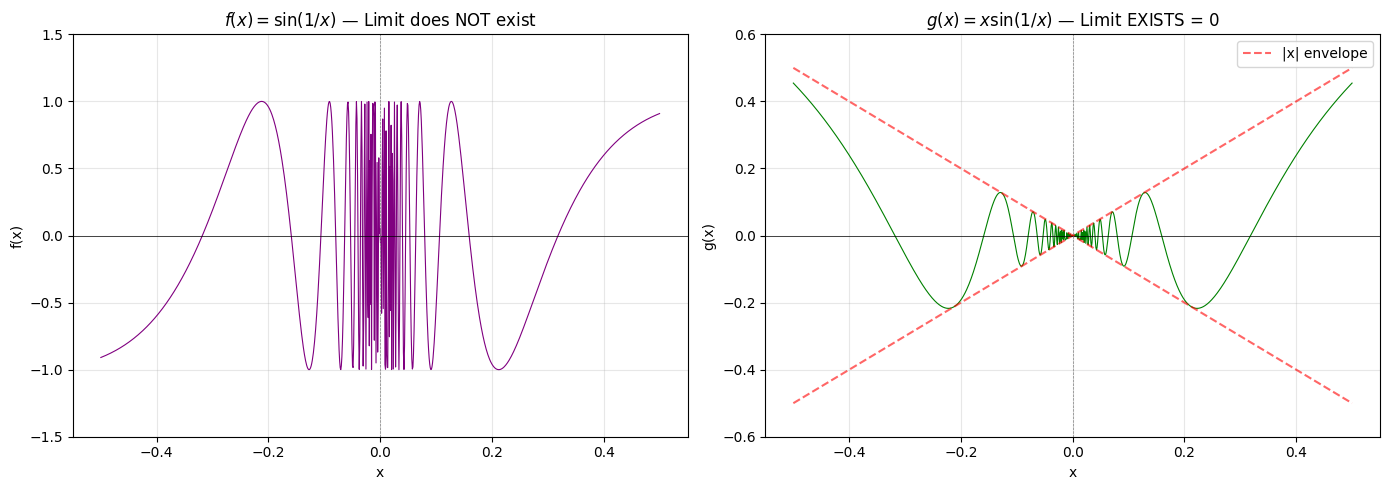

In [27]:
# Contrast: sin(1/x) vs x*sin(1/x)
x_vals = np.linspace(-0.5, 0.5, 1000)
x_vals = x_vals[x_vals != 0]  # Remove exactly 0

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Left: Unbounded oscillation
ax1.plot(x_vals, np.sin(1 / x_vals), color="purple", linewidth=0.8)
ax1.axhline(0, color="black", linewidth=0.5)
ax1.axvline(0, color="gray", linestyle="--", linewidth=0.5)
ax1.set_title(r"$f(x) = \sin(1/x)$ — Limit does NOT exist")
ax1.set_xlabel("x")
ax1.set_ylabel("f(x)")
ax1.set_ylim(-1.5, 1.5)
ax1.grid(True, alpha=0.3)

# Right: Damped oscillation
ax2.plot(x_vals, x_vals * np.sin(1 / x_vals), color="green", linewidth=0.8)
ax2.plot(x_vals, np.abs(x_vals), "--", color="red", alpha=0.6, label="|x| envelope")
ax2.plot(x_vals, -np.abs(x_vals), "--", color="red", alpha=0.6)
ax2.axhline(0, color="black", linewidth=0.5)
ax2.axvline(0, color="gray", linestyle="--", linewidth=0.5)
ax2.set_title(r"$g(x) = x\sin(1/x)$ — Limit EXISTS = 0")
ax2.set_xlabel("x")
ax2.set_ylabel("g(x)")
ax2.set_ylim(-0.6, 0.6)
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

**The Squeeze Theorem in Action**

The right plot illustrates the **Squeeze Theorem** (also called the Sandwich Theorem):

*If $h(x) \leq f(x) \leq g(x)$ for all $x$ near $c$, and $\lim_{x \to c} h(x) = \lim_{x \to c} g(x) = L$, then $\lim_{x \to c} f(x) = L$.*

For $g(x) = x\sin(1/x)$:
- We know $-1 \leq \sin(1/x) \leq 1$
- Multiplying by $|x|$: $-|x| \leq x\sin(1/x) \leq |x|$
- Since $\lim_{x \to 0} |x| = 0$ and $\lim_{x \to 0} -|x| = 0$
- By the Squeeze Theorem: $\lim_{x \to 0} x\sin(1/x) = 0$

The red envelope in the plot shows the "squeeze" in action—the oscillating function is trapped between converging bounds.

**ML Application: Oscillating Gradients**

Wild oscillation appears in ML when:
- Learning rates are too high (gradients bounce around)
- Loss landscapes have sharp ridges (oscillation between steep walls)
- Adversarial training (competing objectives cause instability)

Solutions mirror our mathematical tools:
- **Gradient clipping**: Bounds oscillation (like multiplying by x)
- **Momentum**: Smooths oscillations through averaging
- **Adaptive learning rates**: Adjust step size to reduce bouncing


**5. Limits at Infinity — Asymptotic Behavior**

We can simulate approaching infinity by using large numbers. But this requires understanding what "approaching infinity" means computationally.

**Conceptual Framework:**

When we write $\lim_{x \to \infty} f(x) = L$, we mean:
- For any ε > 0, there exists M such that if x > M, then |f(x) - L| < ε
- In words: eventually (for large enough x), f(x) stays arbitrarily close to L

Numerically, we:
1. Generate a sequence of increasingly large x values
2. Check if f(x) stabilizes to some value L
3. Measure how quickly convergence occurs

**Why Logarithmic Sampling Shines Here:**

For limits at infinity, logarithmic spacing (via `np.logspace`) is almost mandatory:
- It covers multiple orders of magnitude efficiently
- It reveals **power-law** vs **exponential** behavior
- It matches how we think about "large": 10, 100, 1000, 10000, ...

Let's explore several examples to build intuition:

In [28]:
def f_inv(x):
	return 1 / x

In [29]:
# Sequence approaching +infinity
x_pos_inf = np.logspace(1, 6, 100)  # 10^1 to 10^6
y_pos_inf = f_inv(x_pos_inf)

# Sequence approaching -infinity
x_neg_inf = -np.logspace(1, 6, 100)[::-1]  # -(10^6) to -(10^1)
y_neg_inf = f_inv(x_neg_inf)

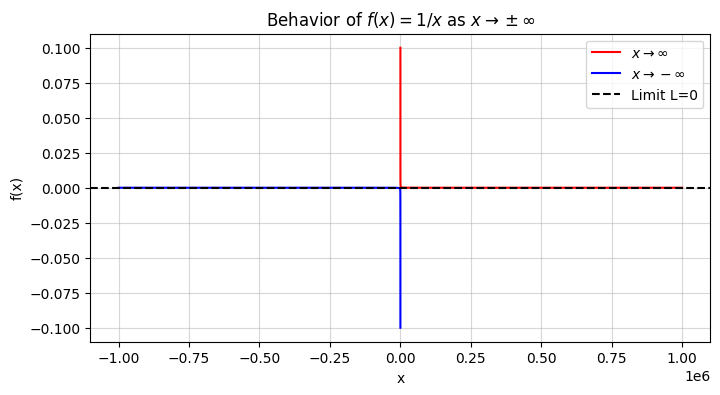

In [30]:
plt.figure(figsize=(8, 4))
plt.plot(x_pos_inf, y_pos_inf, "r-", label=r"$x \to \infty$")
plt.plot(x_neg_inf, y_neg_inf, "b-", label=r"$x \to -\infty$")
plt.axhline(0, color="k", linestyle="--", label="Limit L=0")
plt.title(r"Behavior of $f(x) = 1/x$ as $x \to \pm \infty$")
plt.xlabel("x")
plt.ylabel("f(x)")
plt.legend()
plt.grid(True, alpha=0.5)
# Use symlog scale if needed to see wide range, but linear often clearer for convergence to 0
# plt.xscale('symlog')
plt.show()


The plot shows the function values getting closer and closer to 0 as $x$ moves further away from the origin in either the positive or negative direction, confirming $\lim_{x\to \pm \infty} \frac{1}{x} = 0$.

**Deep Dive: Horizontal Asymptotes**

This function has a **horizontal asymptote** at y = 0. Let's understand this from multiple perspectives:

**1. Algebraic:** As x grows, 1/x shrinks proportionally. Doubling x halves f(x).

**2. Rate of Decay:** On a linear plot, the decay looks fast initially but slows down. On a log-log plot (not shown), it would be a straight line with slope -1, revealing the **power law**: f(x) ∝ x⁻¹.

**3. Numerical Precision:** Eventually, 1/x becomes smaller than machine epsilon and rounds to exactly 0. This is **underflow**, not true convergence, but for practical purposes it's indistinguishable.

**4. Symmetry:** Notice the function approaches 0 from **opposite sides** as x → +∞ vs x → -∞. This antisymmetry (f(-x) = -f(x)) is characteristic of odd functions.

**Comparing Convergence Rates at Infinity:**

Let's examine several functions to understand how different functions approach their asymptotes:

C:\Users\jhonm\AppData\Local\Temp\ipykernel_2268\1615156710.py:9: RuntimeWarning: divide by zero encountered in divide
  "1/log(x) (logarithmic)": lambda x: 1 / np.log(x),


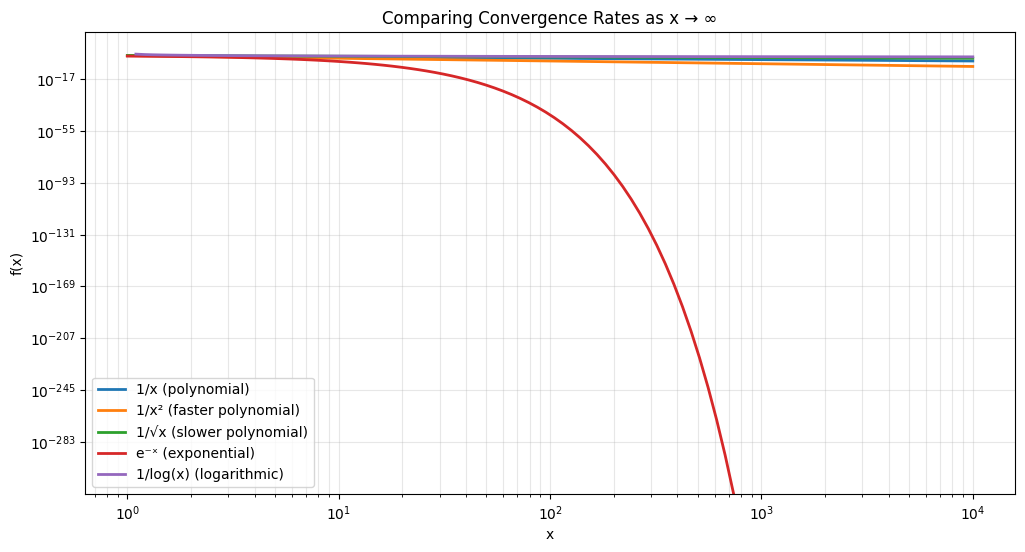

In [31]:
# Compare convergence rates of different functions as x → ∞
x_large = np.logspace(0, 4, 100)  # 1 to 10,000

functions_infinity = {
	"1/x (polynomial)": lambda x: 1 / x,
	"1/x² (faster polynomial)": lambda x: 1 / x**2,
	"1/√x (slower polynomial)": lambda x: 1 / np.sqrt(x),
	"e⁻ˣ (exponential)": lambda x: np.exp(-x),
	"1/log(x) (logarithmic)": lambda x: 1 / np.log(x),
}

plt.figure(figsize=(12, 6))

for name, func in functions_infinity.items():
	plt.loglog(x_large, func(x_large), label=name, linewidth=2)

plt.xlabel("x")
plt.ylabel("f(x)")
plt.title("Comparing Convergence Rates as x → ∞")
plt.legend()
plt.grid(True, which="both", alpha=0.3)
plt.show()

**Interpreting the Convergence Rate Plot**

On a log-log scale, the slope of each line tells us the **rate of convergence**:

1. **e⁻ˣ (exponential)**: Drops vertically off the plot. Exponential decay is *incomparably* faster than polynomial decay. By x=10, it's already negligible.

2. **1/x² (quadratic)**: Straight line with slope -2. Each 10× increase in x produces a 100× decrease in f(x).

3. **1/x (linear)**: Straight line with slope -1. Standard polynomial decay.

4. **1/√x (sublinear)**: Straight line with slope -0.5. Slowest polynomial decay shown.

5. **1/log(x) (logarithmic)**: Curved on log-log plot. *Barely* approaches zero—logarithmic growth is extremely slow, so its reciprocal decays extremely slowly.

**The Hierarchy of Infinity:**

This plot illustrates a fundamental principle: different functions approach infinity (or zero) at vastly different rates. From fastest to slowest decay:

$$e^{-x} \ll \frac{1}{x^2} \ll \frac{1}{x} \ll \frac{1}{\sqrt{x}} \ll \frac{1}{\log x}$$

The symbol $\ll$ means "much faster than" in the asymptotic sense.

**ML Implications:**

These same hierarchies appear in:
- **Regularization strength**: As coefficients grow, L2 penalty (∝ θ²) dominates L1 (∝ |θ|)
- **Activation saturation**: Sigmoid saturates exponentially fast, while linear units never do
- **Learning rate schedules**: 1/√t decay (common in SGD theory) vs 1/t (faster) vs exponential decay (fastest)
- **Convergence guarantees**: Algorithms with O(1/k²) convergence beat O(1/k)

Understanding asymptotic behavior helps choose the right algorithms and hyperparameters.

**Practical heuristics for numeric limit checks**

- Track both the raw distance `|x - c|` and the error `|f(x) - L|`; a log-log plot reveals whether the error shrinks predictably.
- Mix linear and logarithmic sampling so you notice both coarse trends and fine detail.
- Always compare left/right sequences separately before trusting a single limit value.
- If values keep oscillating or alternate between plateaus, treat that as evidence of a missing limit and investigate analytically.
- Reuse helper functions (like `explore_limit`) to keep your experiments reproducible and easy to extend.


  * **Case 4: Vertical Asymptote ($f(x) = 1/x^2$ as $x \to 0$)**

Now let's explore a function with a vertical asymptote, where the function value shoots up to infinity.

In [32]:
def f_asymptote(x):
	# Add a small epsilon to avoid division by zero in the function itself
	return 1 / (x**2 + 1e-15)


c = 0
limit_table = explore_limit(f_asymptote, c=c, n=8)
print("Behavior of f(x) = 1/x^2 near x = 0:")
display(limit_table)

Behavior of f(x) = 1/x^2 near x = 0:


,side,order,x,offset,f_x,distance_from_c
0,left,1,-1.000000,-1.000000,1.000000e+00,1.000000
1,left,2,-0.138950,-0.138950,5.179475e+01,0.138950
2,left,3,-0.019307,-0.019307,2.682696e+03,0.019307
3,left,4,-0.002683,-0.002683,1.389495e+05,0.002683
4,left,5,-0.000373,-0.000373,7.196857e+06,0.000373
5,left,6,-0.000052,-0.000052,3.727592e+08,0.000052
6,left,7,-0.000007,-0.000007,1.930660e+10,0.000007
7,left,8,-0.000001,-0.000001,9.990010e+11,0.000001
8,right,1,1.000000,1.000000,1.000000e+00,1.000000
9,right,2,0.138950,0.138950,5.179475e+01,0.138950


The table clearly shows that as `x` gets closer to 0 from either side (i.e., `distance_from_c` gets smaller), the function value `f_x` grows astronomically. This is the numerical signature of a limit approaching infinity.

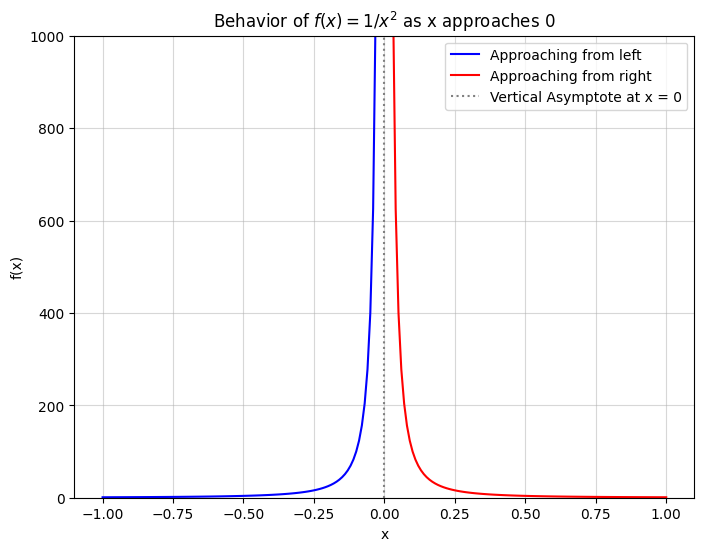

In [33]:
c = 0
num_points = 100

# Generate points for plotting, avoiding c=0
x_left = np.linspace(-1, -0.01, num_points)
y_left = f_asymptote(x_left)

x_right = np.linspace(0.01, 1, num_points)
y_right = f_asymptote(x_right)

plt.figure(figsize=(8, 6))
plt.plot(x_left, y_left, "b-", label="Approaching from left")
plt.plot(x_right, y_right, "r-", label="Approaching from right")

plt.axvline(c, color="gray", linestyle=":", label=f"Vertical Asymptote at x = {c}")
plt.title(r"Behavior of $f(x) = 1/x^2$ as x approaches 0")
plt.xlabel("x")
plt.ylabel("f(x)")
# We need to set a sensible y-limit, otherwise the plot will be unreadable
plt.ylim(0, 1000)
plt.legend()
plt.grid(True, alpha=0.5)
plt.show()

Let's look at a slightly more complex example for limits at infinity: $f(x) = \frac{2x^2 - 1}{x^2 + 1}$. We expect this function to approach the ratio of its leading coefficients, which is 2/1 = 2.

In [34]:
def f_infinity_rational(x):
	return (2 * x**2 - 1) / (x**2 + 1)


# To simulate x -> infinity, we generate points that grow exponentially
x_inf = np.logspace(0, 6, 10)  # from 10^0 to 10^6
y_inf = f_infinity_rational(x_inf)

infinity_df = pd.DataFrame({"x": x_inf, "f(x)": y_inf, "|f(x) - 2|": np.abs(y_inf - 2)})

print("Behavior of f(x) as x -> infinity:")
display(infinity_df)

Behavior of f(x) as x -> infinity:


,x,f(x),|f(x) - 2|
0,1.000000,0.500000,1.500000e+00
1,4.641589,1.866929,1.330711e-01
2,21.544347,1.993551,6.449409e-03
3,100.000000,1.999700,2.999700e-04
4,464.158883,1.999986,1.392470e-05
5,2154.434690,1.999999,6.463303e-07
6,10000.000000,2.000000,3.000000e-08
7,46415.888336,2.000000,1.392477e-09
8,215443.469003,2.000000,6.463297e-11
9,1000000.000000,2.000000,3.000045e-12


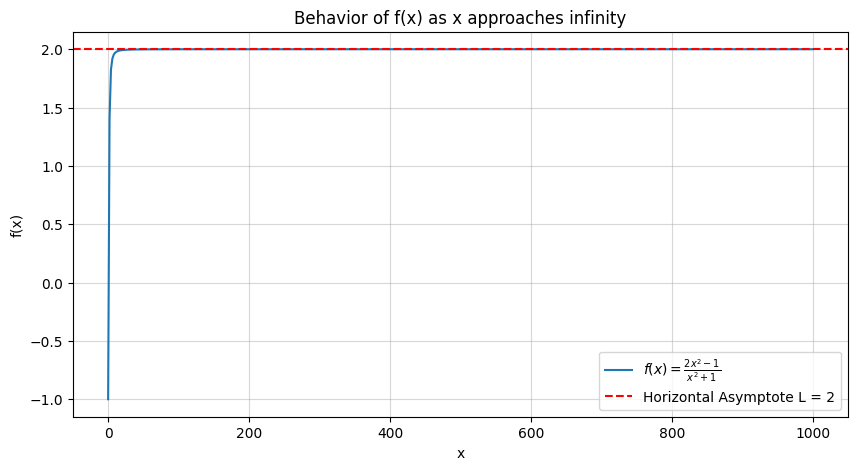

In [35]:
x_plot = np.linspace(0, 1000, 500)
y_plot = f_infinity_rational(x_plot)
limit_val = 2

plt.figure(figsize=(10, 5))
plt.plot(x_plot, y_plot, label=r"$f(x) = \frac{2x^2 - 1}{x^2 + 1}$ ")
plt.axhline(
	limit_val, color="r", linestyle="--", label=f"Horizontal Asymptote L = {limit_val}"
)

plt.title("Behavior of f(x) as x approaches infinity")
plt.xlabel("x")
plt.ylabel("f(x)")
plt.legend()
plt.grid(True, alpha=0.5)
plt.show()

### Conclusion of the Code Approach

Through these examples, we've seen how numerical and visual exploration in Python provides a powerful and intuitive way to understand the concept of limits. By generating sequences of points and observing the function's behavior, we can:

- **Verify** analytical results for simple functions.
- **Build intuition** for what it means for a function to approach a value, even when it's undefined at the target point.
- **Clearly see** why limits sometimes fail to exist, whether due to jumps, oscillations, or unbounded growth.
- **Analyze** the long-term behavior of functions by exploring limits at infinity.

This hands-on approach complements the theoretical framework and is a crucial skill for any data scientist looking to understand the foundations of calculus that underpin so many machine learning algorithms.

**Key Takeaways: From Theory to Practice**

**1. Computational Thinking Builds Mathematical Intuition**

Before this module, you might have thought of limits as purely abstract—epsilon-delta arguments and formal proofs. Now you've seen that limits are **measurable phenomena**. This computational perspective:
- Makes abstract concepts concrete
- Provides immediate feedback (does my conjecture match the data?)
- Reveals edge cases formal methods might miss
- Builds intuition through experimentation

**2. Numerical Methods Have Limits (Pun Intended)**

We've encountered several limitations:
- **Floating-point precision**: Can't go below ~10⁻¹⁵ error
- **Catastrophic cancellation**: Unstable formulas break down
- **Sampling resolution**: Can't capture infinite-frequency oscillations
- **Finite resources**: Can't literally compute at infinity

Understanding these limitations makes you a better computational scientist. You learn to:
- Recognize when numerical results are trustworthy
- Choose stable algorithms over unstable ones
- Design experiments that work within computational constraints
- Validate numerical results against analytical understanding

**3. Visualization is Understanding**

Every plot we created told a story:
- Convergence plots showed *how* functions approach limits
- Log-log plots revealed *power law* relationships
- Side-by-side comparisons highlighted *qualitative differences*
- Error analysis confirmed *theoretical predictions*

Good visualization is not just about pretty pictures—it's about making mathematical relationships visible and intuitive.

**4. The ML Connection is Everywhere**

Throughout this module, we've seen limits appear in:
- **Gradient descent**: Convergence to local minima
- **Loss functions**: Asymptotic behavior and saturation
- **Regularization**: Penalty terms and their effect on convergence
- **Numerical stability**: Why some formulations work better than others
- **Activation functions**: Limiting behavior at extremes
- **Learning rate schedules**: Decay rates and convergence guarantees

Every time you see "as epochs → ∞" or "in the limit of infinite data," you're using limit concepts. Understanding limits deeply makes you a more sophisticated ML practitioner.

**5. The Power of Systematic Exploration**

We developed a **methodology** for investigating limits:

**Step 1:** Choose sampling strategy (linear vs logarithmic)
**Step 2:** Generate sequences approaching the target from both sides
**Step 3:** Evaluate function and measure error
**Step 4:** Visualize convergence (or lack thereof)
**Step 5:** Analyze convergence rate
**Step 6:** Compare with theoretical expectations

This same systematic approach applies to debugging ML models:
- Sample hyperparameter space strategically
- Approach from different initialization
- Measure performance metrics
- Visualize learning curves
- Analyze convergence rates
- Compare with baselines

**6. Building Your Toolkit**

You now have concrete skills:
- `np.linspace` and `np.logspace` for intelligent sampling
- `pandas.DataFrame` for organizing numerical experiments
- `matplotlib` for visualization of convergence
- Log-log plots for analyzing rates
- Helper functions for reusable analysis pipelines

These tools transfer directly to exploratory data analysis, model debugging, and results presentation.

**Next Steps: From Limits to Derivatives**

Limits are the foundation. Next, you'll see how they enable:
- **Derivatives**: $f'(x) = \lim_{h \to 0} \frac{f(x+h) - f(x)}{h}$ (instantaneous rate of change)
- **Integrals**: $\int_a^b f(x)dx = \lim_{n \to \infty} \sum_{i=1}^n f(x_i)\Delta x$ (accumulation)
- **Continuity**: $\lim_{x \to c} f(x) = f(c)$ (no jumps)
- **Series**: $\sum_{n=1}^\infty a_n = \lim_{N \to \infty} \sum_{n=1}^N a_n$ (infinite sums)

Every one of these concepts is a limit in disguise. Master limits, and you've unlocked calculus.

**Final Thought: Computational Mathematics**

We've practiced a style of mathematics that seamlessly blends:
- Rigorous theory (epsilon-delta definitions)
- Numerical computation (NumPy experiments)
- Visual intuition (matplotlib plots)
- Practical application (ML connections)

This is the essence of modern **computational mathematics**—and it's the foundation of data science and machine learning. As you progress, always remember: theory guides computation, computation tests theory, and visualization builds intuition. Together, they're unstoppable.

### Unit 0: Mathematical Foundations & The Analytical Mindset
#### Module 0.3: The Idea of Limits

**(Phase 3: The Practicum)**

These exercises focus on using Python to numerically and visually explore the limits discussed in Phase 1 and Phase 2. You'll generate sequences, evaluate functions, and plot the results to observe convergence or divergence.

**Exercise 1: Observing a Simple Limit**

Consider the function $f(x) = \frac{x^2 - 4}{x - 2}$. We know algebraically this simplifies to $f(x) = x + 2$ for $x \neq 2$ (difference of squares).

1.  Define a Python function `f1(x)` that calculates $\frac{x^2 - 4}{x - 2}$. Use `np.where` or similar logic to handle the case $x=2$ by returning `np.nan` (Not a Number) to represent the undefined point.
2.  Generate two NumPy arrays:
    * `x_left`: Points approaching $c=2$ from the left (e.g., using `2 - np.logspace(-1, -6, 10)`).
    * `x_right`: Points approaching $c=2$ from the right (e.g., using `2 + np.logspace(-6, -1, 10)[::-1]`).
3.  Calculate `y_left = f1(x_left)` and `y_right = f1(x_right)`.
4.  Print the last few values of `x_left`, `y_left`, `x_right`, and `y_right` to observe the numerical convergence. What value do the `y` values seem to approach?
5.  Create a plot showing `y_left` vs `x_left` and `y_right` vs `x_right`. Add a horizontal dashed line at the expected limit $L=4$, a vertical dotted line at $x=2$, and mark the "hole" at $(2, 4)$ with an open circle.

**Deliverable:**
* Python code implementing steps 1-5.
* Printed output from step 4.
* The generated plot from step 5.
* A markdown cell stating the observed limit based on the numerical output and plot.

1.  Define a Python function `f1(x)` that calculates $\frac{x^2 - 4}{x - 2}$. Use `np.where` or similar logic to handle the case $x=2$ by returning `np.nan` (Not a Number) to represent the undefined point.

In [38]:
def f1(x) -> ArrayLike:
	return np.where(x == 2, np.nan, (x**2 - 4) / (x - 2))

2.  Generate two NumPy arrays:
    * `x_left`: Points approaching $c=2$ from the left (e.g., using `2 - np.logspace(-1, -6, 10)`).
    * `x_right`: Points approaching $c=2$ from the right (e.g., using `2 + np.logspace(-6, -1, 10)[::-1]`).

In [40]:
x_left = 2 - np.logspace(-1, -6, 10)
x_right = 2 + np.logspace(-6, -1, 10)[::-1]

3.  Calculate `y_left = f1(x_left)` and `y_right = f1(x_right)`.

array([1.9       , 1.97217441, 1.99225736, 1.99784557, 1.99940052,
       1.99983319, 1.99995358, 1.99998708, 1.99999641, 1.999999  ])

**Exercise 2: Investigating a Limit that Does Not Exist (Jump)**

Consider the function $f(x) = \frac{|x|}{x}$, which is -1 for $x<0$ and +1 for $x>0$. It's undefined at $x=0$.

1.  Define a Python function `f2(x)` that calculates $\frac{|x|}{x}$. (Hint: `np.abs(x)` calculates the absolute value. Handle $x=0$ by returning `np.nan`).
2.  Generate two NumPy arrays:
    * `x_left`: Points approaching $c=0$ from the left (e.g., `-np.logspace(-1, -6, 10)[::-1]`).
    * `x_right`: Points approaching $c=0$ from the right (e.g., `np.logspace(-6, -1, 10)`).
3.  Calculate `y_left = f2(x_left)` and `y_right = f2(x_right)`.
4.  Print the values of `y_left` and `y_right`. What values do they take?
5.  Create a plot showing `y_left` vs `x_left` and `y_right` vs `x_right`. Add horizontal dashed lines at $y=-1$ and $y=1$, and a vertical dotted line at $x=0$.

**Deliverable:**
* Python code implementing steps 1-5.
* Printed output from step 4.
* The generated plot from step 5.
* A markdown cell explaining why the limit $\lim_{x\to 0} \frac{|x|}{x}$ does not exist, based on your observations.

**Exercise 3: Observing a Limit at Infinity**

Consider the function $f(x) = \frac{3x^2 + 2x - 1}{x^2 - 5x + 6}$. We want to explore $\lim_{x\to \infty} f(x)$. Intuitively, for very large $x$, the $x^2$ terms dominate, so we expect the limit to be $\frac{3x^2}{x^2} = 3$.

1.  Define a Python function `f3(x)` for the given rational function.
2.  Generate a NumPy array `x_inf` representing values approaching infinity (e.g., `np.logspace(1, 8, 100)`).
3.  Calculate `y_inf = f3(x_inf)`.
4.  Print the last few values of `x_inf` and `y_inf`. What value does `y_inf` seem to approach?
5.  Create a plot showing `y_inf` vs `x_inf`. Add a horizontal dashed line at the expected limit $L=3$. Use a logarithmic scale for the x-axis (`plt.xscale('log')`) to better visualize the approach over large magnitudes.

**Deliverable:**
* Python code implementing steps 1-5.
* Printed output from step 4.
* The generated plot from step 5.
* A markdown cell confirming the observed limit at infinity.